# Deep learning - Image Classification

## Setup and dependencies 

In [90]:
import random, os
import numpy as np, json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import keras_tuner
import time
import itertools

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"
tf.random.set_seed(42)
np.random.seed(42)
keras.utils.set_random_seed(42)

Function definition

In [2]:
os.makedirs("png", exist_ok=True)

def plot_examples(data, n_rows=4, n_cols=5, save_path="png/examples.png"):
    """Plot a grid of images which are encoded as numpy arrays and save to file."""

    # Remove redundant extra dimension
    if data.shape[-1] == 1:
        data = data.squeeze(axis=-1)

    # Size figure depending on the size of the grid
    plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col
            plt.subplot(n_rows, n_cols, index + 1)
            plt.imshow(data[index])
            plt.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=500) 
    plt.show()
    plt.close()
    print(f"image saved as: {save_path}")


In [34]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Data loading, exploration, and preprocessing


In [18]:
# Load the dataset training and test sets as numpy arrays
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

### 1.1 Examine the shape of the data arrays

In [19]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (50000, 32, 32, 3)
Shape of y_train: (50000,)
Shape of X_test: (10000, 32, 32, 3)
Shape of y_test: (10000,)


### 1.2 Explore the number of classes

In [20]:
cifar10_labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [21]:
# List all unique labels in the training set
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [22]:
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u}: {cifar10_labels[u]} -> {c}")

0: airplane -> 5000
1: automobile -> 5000
2: bird -> 5000
3: cat -> 5000
4: deer -> 5000
5: dog -> 5000
6: frog -> 5000
7: horse -> 5000
8: ship -> 5000
9: truck -> 5000


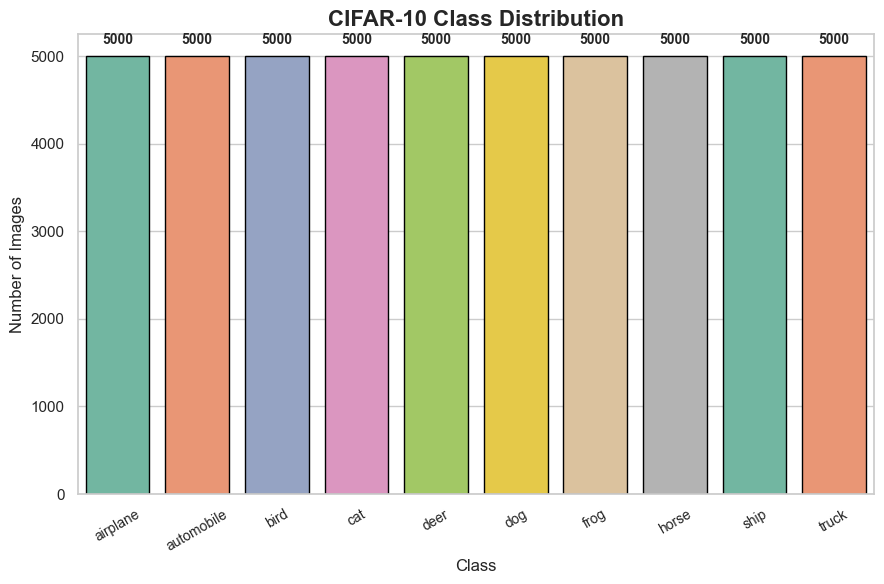

Saved: png/cifar10_class_distribution.png


In [23]:
sns.set(style="whitegrid")

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    x=cifar10_labels, 
    y=counts, 
    hue=cifar10_labels,   
    palette="Set2", 
    edgecolor="black"
)

for i, c in enumerate(counts):
    ax.text(i, c + 100, str(c), ha="center", va="bottom",
            fontsize=10, fontweight="bold")

plt.title("CIFAR-10 Class Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=30, fontsize=10)
plt.tight_layout()

# Save png
out_png = "png/cifar10_class_distribution.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print("Saved:", out_png)

### 1.3 Pixel intensities

In [24]:
# Check whether the pixel values are between 0–255
X_train.dtype

dtype('uint8')

In [25]:
means = X_train.mean(axis=(0,1,2))
stds  = X_train.std(axis=(0,1,2))
print("Channel means:", means)
print("Channel stds:", stds)

Channel means: [125.30691805 122.95039414 113.86538318]
Channel stds: [62.99321928 62.08870764 66.70489964]


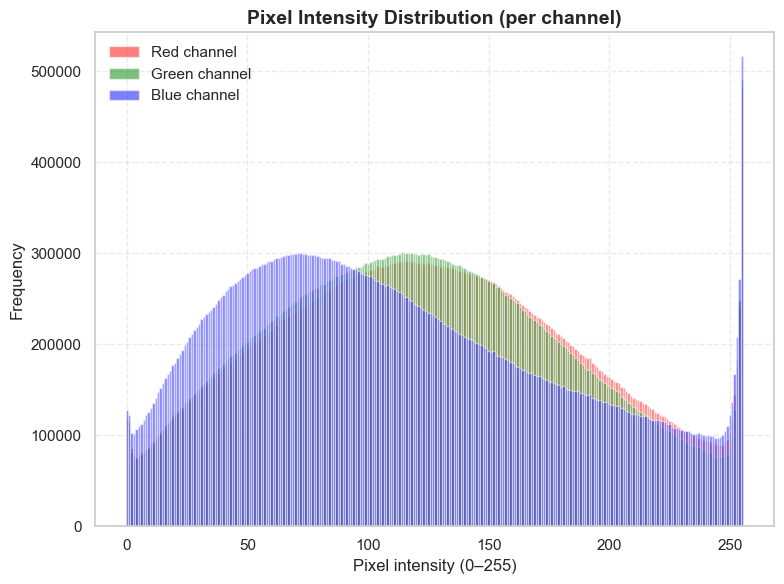

Saved: png/cifar10_class_distribution.png


In [26]:
plt.figure(figsize=(8, 6))

bins = np.arange(257) - 0.5

plt.hist(X_train[..., 0].ravel(), bins=bins, color='red',   alpha=0.5, label='Red channel')
plt.hist(X_train[..., 1].ravel(), bins=bins, color='green', alpha=0.5, label='Green channel')
plt.hist(X_train[..., 2].ravel(), bins=bins, color='blue',  alpha=0.5, label='Blue channel')

plt.title("Pixel Intensity Distribution (per channel)", fontsize=14, fontweight="bold")
plt.xlabel("Pixel intensity (0–255)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Save png
plt.savefig("png/pixel_intensity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_png)

### 1.4 Preprocessing

In [27]:
# Scale the data to the range 0-1
X_train = X_train / 255.
X_test = X_test / 255.

In [28]:
# Create validation set from the training set
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, train_size=0.9, stratify=y_train, random_state=42
)

In [29]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_valid: {X_valid.shape}")
print(f"Shape of y_valid: {y_valid.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (45000, 32, 32, 3)
Shape of y_train: (45000,)
Shape of X_valid: (5000, 32, 32, 3)
Shape of y_valid: (5000,)
Shape of X_test: (10000, 32, 32, 3)
Shape of y_test: (10000,)


### Examples of preprocessed data

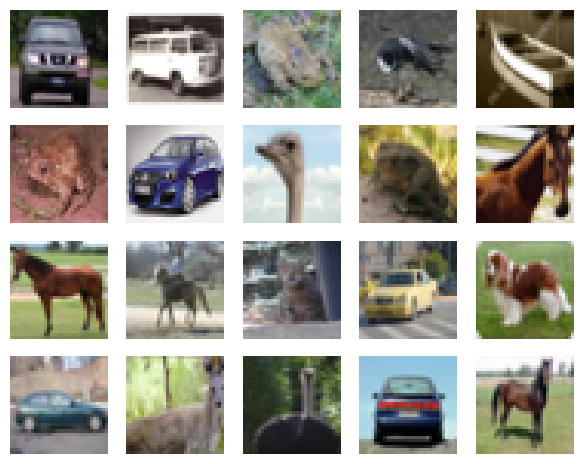

image saved as: png/examples.png


In [31]:
plot_examples(X_train)

## 2. Algorithm design and setup

### 2.1 SVM
Machine learning algorithms like SVM cannot directly input images; the data must be flattened (50,000, 32×32×3).

However, 32×32×3 represents too many features for a single data point. Therefore, for SVMs, we need to perform PCA.

#### 2.1.1 PCA
This data will be specifically given to SVM

Before PCA: (45000, 3072)


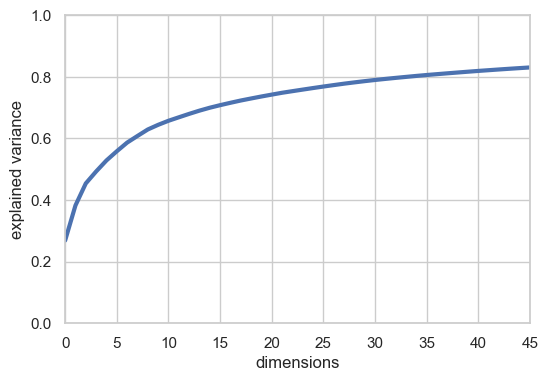

After PCA: (45000, 221)


In [32]:
# Flatten + Standardization + PCA
# 1. flatten
Xtr_flat = X_train.reshape(len(X_train), -1)
Xva_flat = X_valid.reshape(len(X_valid), -1)
Xte_flat = X_test.reshape(len(X_test), -1)

print("Before PCA:", Xtr_flat.shape)   

# 2. Standardization
scaler = StandardScaler(with_mean=True)
X_train_norm = scaler.fit_transform(Xtr_flat)
X_valid_norm = scaler.transform(Xva_flat)
X_test_norm  = scaler.transform(Xte_flat)

# 3. PCA
pca = PCA(random_state=42)
pca.fit(X_train_norm)
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance vs number of dimensions
plt.figure(figsize = (6,4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 45, 0, 1]) 
plt.xlabel("dimensions")
plt.ylabel("explained variance")
plt.grid(True)
plt.show()

pca=PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_norm)
X_valid_pca = pca.transform(X_valid_norm)
X_test_pca  = pca.transform(X_test_norm)

print("After PCA:", X_train_pca.shape)  

#### 2.1.2 Rough experiments to converge on a reasonable design
Before adjusting parameters, we need to fix an instance. We will then adjust hyperparameters based on this instance model.

We will select the kernel function with better performance from the three kernel functions we learned in class. Other hyperparameters will remain unchanged.

In [33]:
def build_svm(kernel="rbf", C=1.0, gamma="scale", degree=3):
    return SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)

results = {}

# Pilot compares rbf vs linear for speed/stability
for kernel in ["rbf", "linear"]:
    clf = build_svm(kernel=kernel)

    idx = np.random.choice(len(X_train_pca), 3000, replace=False)
    Xtr_sub, ytr_sub = X_train_pca[idx], y_train[idx]
    clf.fit(Xtr_sub, ytr_sub)

    val_acc = clf.score(X_valid_pca, y_valid)
    results[kernel] = val_acc
    print(f"{kernel}: val acc = {val_acc:.4f}")

print("\nSummary:", results)

rbf: val acc = 0.4180
linear: val acc = 0.2734

Summary: {'rbf': 0.418, 'linear': 0.2734}


Based on the above analysis, we will choose rbf kernel.

### 2.2 Fully connected neural network

#### 2.2.1 Rough experiments to converge on a reasonable design
The input layer and output layer are fixed, but we need to roughly determine how many hidden layers are appropriate. 

After determining the hidden layers, we can adjust the hyperparameters.

Mainly to observe when convergence

In [35]:
def build_mlp(hidden_layer_list, input_shape=(32,32,3), n_classes=10):
    #Constructing a MLP from a list of hidden layer widths

    # Input layer: 32*32*3 + flattening
    model = keras.models.Sequential([keras.layers.Input(shape=input_shape),
                                     keras.layers.Flatten()])
    
    # Hidden layer
    # The number of neurons and activation function are fixed. 
    # We do not need to determine which activation function and which number of neurons are better. 
    # We just simply find the most suitable hidden layers.
    for h in hidden_layer_list:
        model.add(keras.layers.Dense(h, activation="tanh"))

    # Output layer
    model.add(keras.layers.Dense(n_classes, activation="softmax"))

    # Similar to the setting of hidden layer, the optimizer and loss function are fixed first. 
    # These parameters will be discussed in detail in hyperparameter adjustment.
    opt = keras.optimizers.SGD(learning_rate=5e-2)
    model.compile(optimizer=opt,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    
    return model


In [63]:
# For time considerations, we only will consider 1, 2, 3, and 4 hidden layers.
candidates = {
    "1-layer": [150],
    "2-layer": [150, 150],   
    "3-layer": [150, 150, 150],
    "4-layer": [150, 150, 150, 150],
}

results = {}
for name, units in candidates.items():
    print(f"\n=== Training {name} MLP ===")
    model = build_mlp(units)
    
    history = model.fit(X_train, y_train,
                        validation_data=(X_valid, y_valid),
                        epochs=20, batch_size=64, verbose=0)
    
    val_acc = history.history["val_accuracy"][-1]
    results[name] = val_acc
    print(f"{name}: final val acc = {val_acc:.4f}")

print("\nSummary:", results)


=== Training 1-layer MLP ===
1-layer: final val acc = 0.3578

=== Training 2-layer MLP ===
2-layer: final val acc = 0.4238

=== Training 3-layer MLP ===
3-layer: final val acc = 0.4574

=== Training 4-layer MLP ===
4-layer: final val acc = 0.4326

Summary: {'1-layer': 0.3578000068664551, '2-layer': 0.423799991607666, '3-layer': 0.45739999413490295, '4-layer': 0.4325999915599823}


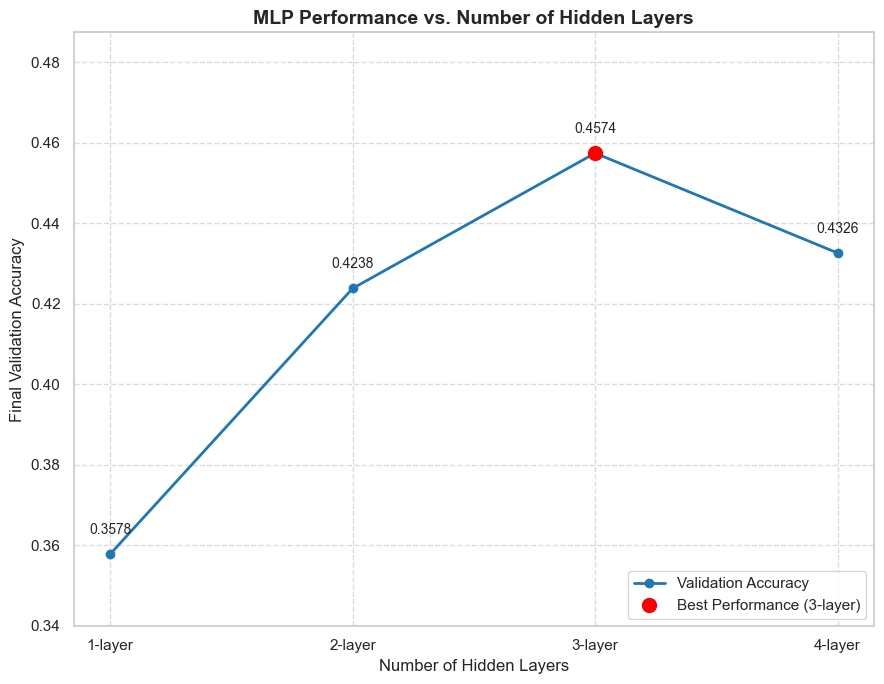

In [64]:
# Plot the hidden layer impact
labels = list(results.keys())
accuracy = list(results.values())

layer_counts = [int(name.split('-')[0]) for name in labels] 

best_acc = max(accuracy)
best_index = accuracy.index(best_acc)
best_layer = layer_counts[best_index]

plt.figure(figsize=(9, 7))
plt.plot(layer_counts, accuracy, marker='o', linestyle='-', color='tab:blue', linewidth=2, label='Validation Accuracy')

for i, acc in enumerate(accuracy):
    plt.text(layer_counts[i], acc + 0.005, f'{acc:.4f}', ha='center', fontsize=10)
    
plt.scatter(best_layer, best_acc, color='red', s=100, zorder=5, label=f'Best Performance ({labels[best_index]})')

plt.ylim(min(accuracy) * 0.95, max(accuracy) + 0.03) 

plt.title('MLP Performance vs. Number of Hidden Layers', fontsize=14, fontweight='bold')
plt.xlabel('Number of Hidden Layers', fontsize=12)
plt.ylabel('Final Validation Accuracy', fontsize=12)

plt.xticks(layer_counts, labels) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout() 

file_name = 'MLP_Hyperparameter_Tuning_Layers.png'
plt.savefig(file_name, dpi=300)

plt.show()

Running the above code multiple times will produce different output results. We found that 3 and 4 hidden layers generally give the best results. 

Due to time constraints, we chose 3 hidden layers.


#### 2.2.2 Hyperparameters set up

In [66]:
def build_mlp_tune(hp):
    model = keras.Sequential()
    
    # Input & Flatten for CIFAR-10 (32x32x3)
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Flatten())

    # Add 3 hidden layers
    # The number of neurons and activation function as hyperparameter objects
    for i in range(1, 4):
        model.add(
            keras.layers.Dense(
                units=hp.Choice(f"units_{i}", values=[256, 512]),
                activation=hp.Choice("activation", values=["relu", "sigmoid", "tanh"])
            )
        )
    # Add the output layer for 10 class classification
    model.add(keras.layers.Dense(10, activation="softmax"))

     # Learning rate and optimizer as hyperparameters
    learning_rate = hp.Choice("learning_rate", values=[0.001, 0.0001, 0.00001])
    optimizer_name = hp.Choice("optimizer", values=["SGD", "Adam"])
    
    if optimizer_name == "SGD":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else: #Adam
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### 2.3 Convolutional neural network

#### 2.3.1 Rough experiments to converge on a reasonable design


In [40]:
def build_cnn(conv_filters, input_shape=(32,32,3), n_classes=10):
    # Constructing a CNN from a list of convolutional layers
    # Each element of the list represents the number of filters in a convolutional block; each block is fixed to:
    # Conv2D(3x3, relu, same) -> MaxPool(2x2)
    
    model = keras.Sequential()

    # Input Layer
    model.add(keras.layers.Input(shape=input_shape))

    # Convolution layer + pooling layer
    for f in conv_filters:
        model.add(keras.layers.Conv2D(filters=f, kernel_size=(3,3),
                                      activation="relu", padding="same"))
        model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

    # Flatten conversion → Dropout to prevent overfitting → Fully connected layer output
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dropout(0.5))            
    model.add(keras.layers.Dense(n_classes, activation="softmax"))

    # The optimizer and loss function are fixed first.
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model



=== Training 1-conv CNN ===
1-conv: final val acc = 0.6328

=== Training 2-conv CNN ===
2-conv: final val acc = 0.6764

=== Training 3-conv CNN ===
3-conv: final val acc = 0.6530

Summary: {'1-conv': 0.6327999830245972, '2-conv': 0.6764000058174133, '3-conv': 0.652999997138977}


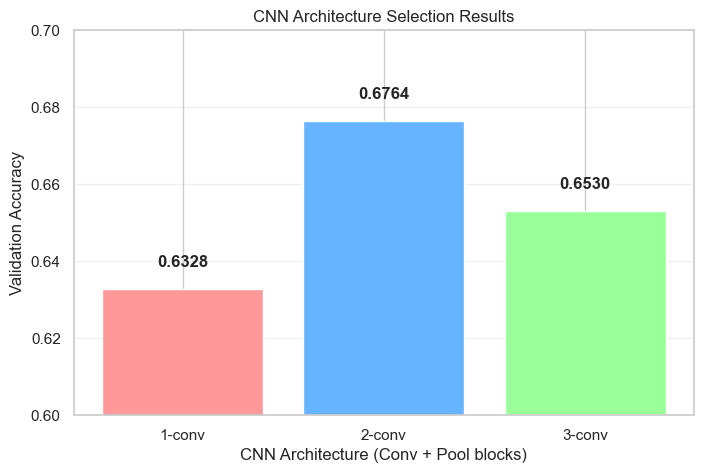

In [41]:
# To keep time manageable, only 1, 2 and 3 convolutional blocks are compared (each block = Conv + Pool).
candidates = {
    "1-conv": [32],
    "2-conv": [32, 32],
    "3-conv": [32, 32, 32],
}

results = {}
for name, conv_filters in candidates.items():
    print(f"\n=== Training {name} CNN ===")
    model = build_cnn(conv_filters)
    history = model.fit(X_train, y_train,
                        validation_data=(X_valid, y_valid),
                        epochs=10, batch_size=128, verbose=0)
    val_acc = history.history["val_accuracy"][-1]
    results[name] = val_acc
    print(f"{name}: final val acc = {val_acc:.4f}")

print("\nSummary:", results)

# Plot barplots 
CNN_architectures = list(results.keys())
CNN_accuracies = list(results.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(CNN_architectures, CNN_accuracies, color=['#ff9999', '#66b3ff', '#99ff99'])
plt.ylabel('Validation Accuracy')
plt.xlabel('CNN Architecture (Conv + Pool blocks)')
plt.title('CNN Architecture Selection Results')
plt.ylim(0.6, 0.7)


for bar, acc in zip(bars, CNN_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.savefig('cnn_architecture_selection.png', dpi=300, bbox_inches='tight')
plt.show()

Similarly, after running the above code several times, we found that in most cases, the two convolutional layers work best.

Based on the above analysis, we will choose 2 convolutional layers and pooling layers.

#### 2.3.2 Hyperparameters set up

In [42]:
def build_cnn_tune(hp, input_shape=(32,32,3), n_classes=10):
    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    # Three convolution + pooling modules
    for i in range(1, 3):
        model.add(
            layers.Conv2D(
                filters=hp.Choice(f"filters_{i}", values=[32, 64, 128]),
                kernel_size=hp.Choice(f"kernel_size_{i}", values=[3, 5]),
                activation=hp.Choice("activation", values=["relu", "tanh", "sigmoid"]),
                padding=hp.Choice("padding", values=["same", "valid"])  
            )
        )
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten conversion → Dropout to prevent overfitting → Fully connected layer output
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(n_classes, activation="softmax"))

    # The optimizer is fixed Adam, only the learning rate is adjusted
    learning_rate = hp.Choice("learning_rate", values=[0.001, 0.0001, 0.00001])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

## 3. Hyperparameter tuning

### 3.1 Algorithm of choice from first six weeks of course

In CNNs and MLPs, a portion of the training set needs to be extracted as a validation set. 

In SVM, since we use cross-validation, the validation set is merged back into the training set (The test set is not used at all here, as it is used to determine the performance of the model with the optimal hyperparameters.)

#### 3.1.1 Pilot tuning

In [43]:
# Prepare flattened inputs (no PCA here; PCA will be inside the Pipeline)
Xtr_flat_full = np.concatenate([
    X_train.reshape(len(X_train), -1),
    X_valid.reshape(len(X_valid), -1)
], axis=0)
ytr_full = np.concatenate([y_train, y_valid], axis=0)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.9, random_state=42)
(train_idx, _) = next(sss.split(Xtr_flat_full, ytr_full))
Xpilot, ypilot = Xtr_flat_full[train_idx], ytr_full[train_idx]

kernels = ["rbf"]
pilot_results = {}

for k in kernels:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("pca", PCA(n_components=256, random_state=42)),
        ("svm", SVC(kernel=k))
    ])
    
    param_grid_pilot = {
        "svm__C":     [0.1, 1, 10],
        "svm__gamma": [0.001, 0.01, 0.1],
    }
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_pilot,
        cv=3,
        n_jobs=1,
        return_train_score=False,
        verbose=3    
    )
    t0 = time.time()
    gs.fit(Xpilot, ypilot)
    elapsed = time.time() - t0
    pilot_results[k] = {
        "best_params": gs.best_params_,
        "best_score": gs.best_score_,
        "time_s": elapsed,
    }
    print(f"Kernel={k}: best CV acc={gs.best_score_:.4f}, time={elapsed:.1f}s, params={gs.best_params_}")

# Choose kernel with higher pilot CV score
chosen_kernel = max(pilot_results.items(), key=lambda kv: kv[1]["best_score"])[0]
print("Chosen kernel for full grid:", chosen_kernel)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV 1/3] END ......svm__C=0.1, svm__gamma=0.001;, score=0.208 total time=  19.7s
[CV 2/3] END ......svm__C=0.1, svm__gamma=0.001;, score=0.239 total time=  18.7s
[CV 3/3] END ......svm__C=0.1, svm__gamma=0.001;, score=0.188 total time=  18.8s
[CV 1/3] END .......svm__C=0.1, svm__gamma=0.01;, score=0.102 total time=  18.7s
[CV 2/3] END .......svm__C=0.1, svm__gamma=0.01;, score=0.102 total time=  20.1s
[CV 3/3] END .......svm__C=0.1, svm__gamma=0.01;, score=0.105 total time=  19.3s
[CV 1/3] END ........svm__C=0.1, svm__gamma=0.1;, score=0.158 total time=  20.8s
[CV 2/3] END ........svm__C=0.1, svm__gamma=0.1;, score=0.148 total time=  21.7s
[CV 3/3] END ........svm__C=0.1, svm__gamma=0.1;, score=0.159 total time=  21.6s
[CV 1/3] END ........svm__C=1, svm__gamma=0.001;, score=0.406 total time=  19.2s
[CV 2/3] END ........svm__C=1, svm__gamma=0.001;, score=0.395 total time=  20.7s
[CV 3/3] END ........svm__C=1, svm__gamma=0.001;,

#### 3.1.2 Focused Grid Search & Full-Train Recheck

In [44]:
# --- 1. Setup: centers, tuning set, pipeline, CV ---
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# centers from 3.1.1 
C0     = float(pilot_results["rbf"]["best_params"]["svm__C"])
gamma0 = float(pilot_results["rbf"]["best_params"]["svm__gamma"])

# use ≤12k stratified subset for rbf
if len(ytr_full) > 12000:
    frac = 12000 / len(ytr_full)
    sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=42)
    (idx, _), = sss.split(Xtr_flat_full, ytr_full)
    Xb, yb = Xtr_flat_full[idx], ytr_full[idx]
else:
    Xb, yb = Xtr_flat_full, ytr_full

# pipeline (avoid leakage)
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("pca", PCA(n_components=256, random_state=42)),
    ("svm", SVC(kernel=chosen_kernel, probability=False, cache_size=2000)),
])

print(f"kernel={chosen_kernel} | centers: C0={C0}, gamma0={gamma0} | tuning size={len(yb)}")

kernel=rbf | centers: C0=10.0, gamma0=0.001 | tuning size=12000


In [45]:
# --- 2. Local 5×5 grid with automatic boundary expansion (max 2 extra rounds) ---
MAX_EXPAND = 2
Cc, Gc = C0, gamma0
last_cv_results, last_best_params = None, None

for r in range(1, MAX_EXPAND + 2):  # initial + up to 2 expansions
    C_list    = [Cc/5, Cc/2, Cc, Cc*2, Cc*5]
    gamma_list = [Gc/5, Gc/2, Gc, Gc*2, Gc*5]
    param_grid = {"svm__C": C_list, "svm__gamma": gamma_list}

    print(f"\n[Round {r}] grid = {param_grid}")
    gs = GridSearchCV(pipe, param_grid, cv=cv3, n_jobs=1, return_train_score=False, verbose=2)
    gs.fit(Xb, yb)
    last_cv_results = gs.cv_results_
    last_best_params = gs.best_params_
    print(f"[Round {r}] best on subset: acc={gs.best_score_:.4f}, params={gs.best_params_}")

    # per-candidate summary (mean±std + mean_fit_time)
    print(f"[Round {r}] candidate summary:")
    for i in range(len(last_cv_results["params"])):
        p = last_cv_results["params"][i]
        m = float(last_cv_results["mean_test_score"][i])
        s = float(last_cv_results["std_test_score"][i])
        t = float(last_cv_results["mean_fit_time"][i])
        g = p.get("svm__gamma", None)
        print(f"  [{i+1:02d}] C={p['svm__C']}" + (f", gamma={g}" if g is not None else "") +
              f" → CV acc={m:.4f} ± {s:.4f}, fit={t:.1f}s")

    # boundary check → expand if the best lies on an edge; otherwise stop
    on_C_edge = (last_best_params["svm__C"] == min(C_list)) or (last_best_params["svm__C"] == max(C_list))
    on_G_edge = (last_best_params["svm__gamma"] == min(gamma_list)) or (last_best_params["svm__gamma"] == max(gamma_list))
    if not (on_C_edge or on_G_edge):
        break  # already centered; no need to expand further
    Cc = last_best_params["svm__C"]
    Gc = last_best_params["svm__gamma"]


[Round 1] grid = {'svm__C': [2.0, 5.0, 10.0, 20.0, 50.0], 'svm__gamma': [0.0002, 0.0005, 0.001, 0.002, 0.005]}
Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END ......................svm__C=2.0, svm__gamma=0.0002; total time= 1.1min
[CV] END ......................svm__C=2.0, svm__gamma=0.0002; total time= 1.1min
[CV] END ......................svm__C=2.0, svm__gamma=0.0002; total time= 1.1min
[CV] END ......................svm__C=2.0, svm__gamma=0.0005; total time= 1.0min
[CV] END ......................svm__C=2.0, svm__gamma=0.0005; total time= 1.0min
[CV] END ......................svm__C=2.0, svm__gamma=0.0005; total time= 1.1min
[CV] END .......................svm__C=2.0, svm__gamma=0.001; total time= 1.2min
[CV] END .......................svm__C=2.0, svm__gamma=0.001; total time= 1.2min
[CV] END .......................svm__C=2.0, svm__gamma=0.001; total time= 1.2min
[CV] END .......................svm__C=2.0, svm__gamma=0.002; total time= 1.2min
[CV] END ........


=== Grid Search Results Analysis ===
Total configurations tested: 25

Top 5 configurations:
  C=4, gamma=0.0005 → acc=0.4778±0.0047, time=51.9s
  C=2, gamma=0.0005 → acc=0.4757±0.0035, time=45.9s
  C=2, gamma=0.00025 → acc=0.4714±0.0049, time=37.2s
  C=4, gamma=0.00025 → acc=0.4710±0.0080, time=40.8s
  C=10, gamma=0.0005 → acc=0.4700±0.0060, time=53.3s


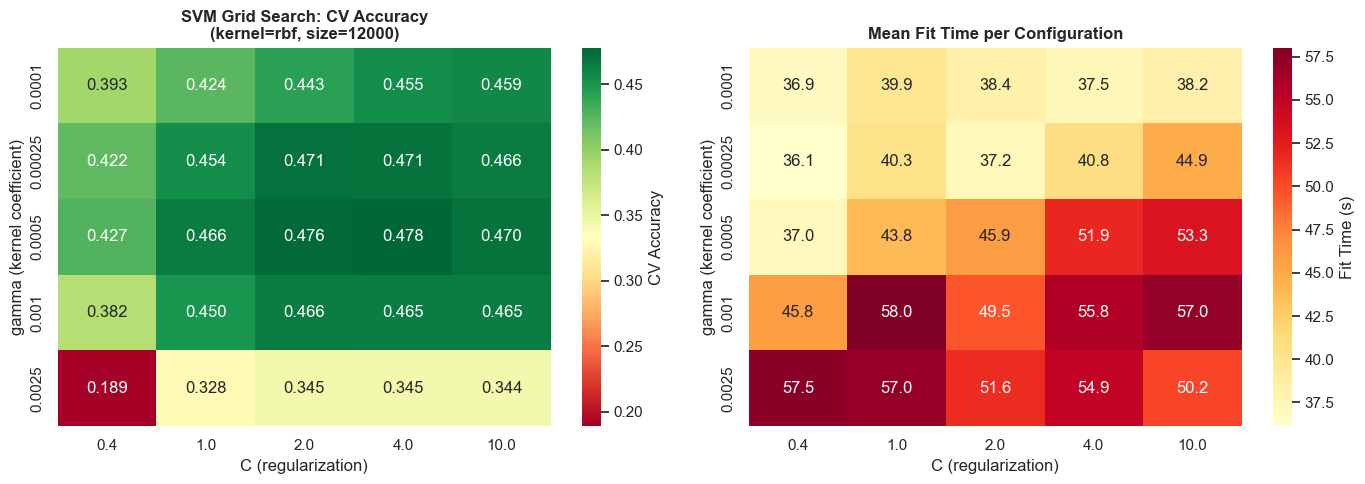


Saved: png/svm_gridsearch_heatmap.png


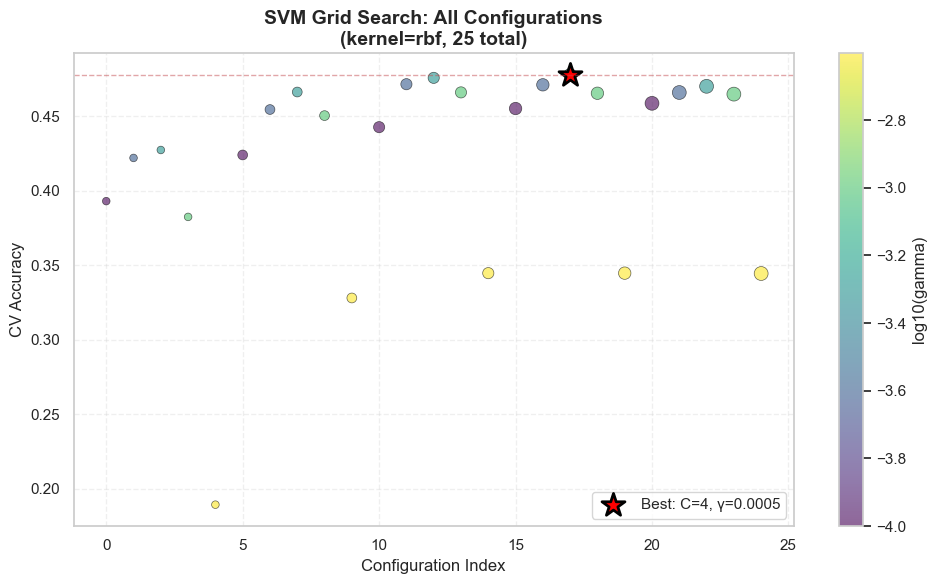

Saved: png/svm_gridsearch_scatter.png

=== Summary Statistics ===
Best accuracy: 0.4778
Mean accuracy: 0.4222
Std accuracy: 0.0680
Average time per config: 46.4s


In [47]:
# --- Visualization of Grid Search Results ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Convert results to DataFrame
results_df = pd.DataFrame(last_cv_results)

print("\n=== Grid Search Results Analysis ===")
print(f"Total configurations tested: {len(results_df)}")
print(f"\nTop 5 configurations:")
top5 = results_df.nlargest(5, 'mean_test_score')[
    ['param_svm__C', 'param_svm__gamma', 'mean_test_score', 'std_test_score', 'mean_fit_time']
]
for idx, row in top5.iterrows():
    print(f"  C={row['param_svm__C']:.4g}, gamma={row['param_svm__gamma']:.4g} "
          f"→ acc={row['mean_test_score']:.4f}±{row['std_test_score']:.4f}, "
          f"time={row['mean_fit_time']:.1f}s")

# Visualization 1: Heatmap of CV Accuracy (RBF only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data for heatmap
results_df['C'] = results_df['param_svm__C'].astype(float)
results_df['gamma'] = results_df['param_svm__gamma'].astype(float)

pivot_acc = results_df.pivot_table(
    values='mean_test_score',
    index='gamma',
    columns='C'
)

# Heatmap 1: Accuracy
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='RdYlGn',
            cbar_kws={'label': 'CV Accuracy'}, ax=axes[0],
            vmin=pivot_acc.min().min(), vmax=pivot_acc.max().max())
axes[0].set_title(f'SVM Grid Search: CV Accuracy\n(kernel={chosen_kernel}, size={len(yb)})',
                  fontweight='bold')
axes[0].set_xlabel('C (regularization)')
axes[0].set_ylabel('gamma (kernel coefficient)')

# Heatmap 2: Training Time
pivot_time = results_df.pivot_table(
    values='mean_fit_time',
    index='gamma',
    columns='C'
)
sns.heatmap(pivot_time, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Fit Time (s)'}, ax=axes[1])
axes[1].set_title('Mean Fit Time per Configuration', fontweight='bold')
axes[1].set_xlabel('C (regularization)')
axes[1].set_ylabel('gamma (kernel coefficient)')

plt.tight_layout()
plt.savefig('png/svm_gridsearch_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: png/svm_gridsearch_heatmap.png")

# Visualization 2: Accuracy vs Parameters (scatter plot, RBF only)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

scatter = ax.scatter(
    range(len(results_df)),
    results_df['mean_test_score'],
    c=np.log10(results_df['gamma']),
    s=np.log10(results_df['C']) * 50 + 50,
    alpha=0.6,
    cmap='viridis',
    edgecolors='black',
    linewidths=0.5
)

# Mark best configuration
best_idx = results_df['mean_test_score'].idxmax()
ax.scatter(best_idx, results_df.loc[best_idx, 'mean_test_score'],
           s=300, c='red', marker='*', edgecolors='black', linewidths=2,
           label=f'Best: C={results_df.loc[best_idx, "param_svm__C"]:.4g}, '
                 f'γ={results_df.loc[best_idx, "param_svm__gamma"]:.4g}')

plt.colorbar(scatter, label='log10(gamma)', ax=ax)
ax.legend(loc='lower right')

ax.set_xlabel('Configuration Index', fontsize=12)
ax.set_ylabel('CV Accuracy', fontsize=12)
ax.set_title(f'SVM Grid Search: All Configurations\n(kernel={chosen_kernel}, {len(results_df)} total)',
             fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=results_df['mean_test_score'].max(), color='r', linestyle='--',
           linewidth=1, alpha=0.5, label='Best score')

plt.tight_layout()
plt.savefig('png/svm_gridsearch_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: png/svm_gridsearch_scatter.png")

# Summary statistics
print("\n=== Summary Statistics ===")
print(f"Best accuracy: {results_df['mean_test_score'].max():.4f}")
print(f"Mean accuracy: {results_df['mean_test_score'].mean():.4f}")
print(f"Std accuracy: {results_df['mean_test_score'].std():.4f}")
print(f"Average time per config: {results_df['mean_fit_time'].mean():.1f}s")

In [48]:
# --- 3. Recheck top-k on FULL train + save best to best_svm.json ---
top_k = min(3, len(last_cv_results["params"]))
order = np.argsort(-last_cv_results["mean_test_score"])[:top_k]
cands = [last_cv_results["params"][i] for i in order]
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_params_final, best_cv_full = None, -1.0

print("\n Re-check top candidates on FULL train")
for j, p in enumerate(cands, 1):
    pipe_full = Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("pca", PCA(n_components=256, random_state=42)),
        ("svm", SVC(kernel=chosen_kernel, probability=False, cache_size=2000)),
    ])
    pipe_full.set_params(**p)
    s = cross_val_score(pipe_full, Xtr_flat_full, ytr_full, cv=cv5, n_jobs=1)
    mean_s, std_s = float(s.mean()), float(s.std())
    print(f"  ({j}/{len(cands)}) params={p} → FULL-train CV acc={mean_s:.4f} ± {std_s:.4f}")
    if mean_s > best_cv_full:
        best_cv_full, best_params_final = mean_s, p

print(f"\n FINAL after full-train recheck: acc={best_cv_full:.4f}, params={best_params_final}")

with open("best_svm.json", "w") as f:
    json.dump({
        "kernel": chosen_kernel,
        "C": float(best_params_final["svm__C"]),
        "gamma": float(best_params_final["svm__gamma"]) if chosen_kernel == "rbf" else None,
        "cv": 5,
        "pca_n": 256,
        "note": "local 5x5, boundary expansion, top-k full recheck"
    }, f)
print("Saved to best_svm.json")


 Re-check top candidates on FULL train
  (1/3) params={'svm__C': 4.0, 'svm__gamma': 0.0005} → FULL-train CV acc=0.5587 ± 0.0045
  (2/3) params={'svm__C': 2.0, 'svm__gamma': 0.0005} → FULL-train CV acc=0.5568 ± 0.0045
  (3/3) params={'svm__C': 2.0, 'svm__gamma': 0.00025} → FULL-train CV acc=0.5433 ± 0.0062

 FINAL after full-train recheck: acc=0.5587, params={'svm__C': 4.0, 'svm__gamma': 0.0005}
Saved to best_svm.json


### 3.2 Fully connected neural network

In [105]:
# Using random search for hyperparameter selection
mlp_tuner = keras_tuner.RandomSearch(
    hypermodel=build_mlp_tune,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuning_results",
    project_name="mlp_tuning",
    seed=42
)

In [106]:
# View the search space (what hyperparameters are there)
mlp_tuner.search_space_summary()

Search space summary
Default search space size: 6
units_1 (Choice)
{'default': 256, 'conditions': [], 'values': [256, 512], 'ordered': True}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh'], 'ordered': False}
units_2 (Choice)
{'default': 256, 'conditions': [], 'values': [256, 512], 'ordered': True}
units_3 (Choice)
{'default': 256, 'conditions': [], 'values': [256, 512], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001, 1e-05], 'ordered': True}
optimizer (Choice)
{'default': 'SGD', 'conditions': [], 'values': ['SGD', 'Adam'], 'ordered': False}


In [107]:
# Start the search: train and evaluate different hyperparameter combinations
mlp_t0 = time.time()
mlp_tuner.search(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    batch_size=128,
)
mlp_t1 = time.time()
elapsed = mlp_t1 - mlp_t0
print(f"\n[Search finished] Total elapsed time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

Trial 10 Complete [00h 00m 36s]
val_accuracy: 0.13920000195503235

Best val_accuracy So Far: 0.515999972820282
Total elapsed time: 00h 06m 53s

[Search finished] Total elapsed time: 413.11 seconds (6.89 minutes)


In [108]:
# overview of the trials
mlp_tuner.results_summary()

Results summary
Results in keras_tuning_results\mlp_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
units_1: 256
activation: relu
units_2: 256
units_3: 512
learning_rate: 0.0001
optimizer: Adam
Score: 0.515999972820282

Trial 05 summary
Hyperparameters:
units_1: 256
activation: relu
units_2: 512
units_3: 256
learning_rate: 0.0001
optimizer: Adam
Score: 0.5080000162124634

Trial 08 summary
Hyperparameters:
units_1: 256
activation: relu
units_2: 256
units_3: 256
learning_rate: 0.001
optimizer: Adam
Score: 0.4803999960422516

Trial 01 summary
Hyperparameters:
units_1: 512
activation: relu
units_2: 256
units_3: 256
learning_rate: 1e-05
optimizer: Adam
Score: 0.4578000009059906

Trial 06 summary
Hyperparameters:
units_1: 512
activation: relu
units_2: 256
units_3: 512
learning_rate: 0.001
optimizer: SGD
Score: 0.38260000944137573

Trial 02 summary
Hyperparameters:
units_1: 512
activation: relu
units_2: 512
units_3: 256
learning

In [128]:
# Read oracle.json and calculate trial time
oracle_path = os.path.join("keras_tuning_results", "mlp_tuning", "oracle.json")

with open(oracle_path, "r") as f:
    oracle_data = json.load(f)

trial_start = oracle_data["display"]["trial_start"]

# Convert the string to a pandas datetime and calculate the time difference
trial_times = {}
sorted_ids = sorted(trial_start.keys(), key=lambda x: int(x))
for i in range(len(sorted_ids)-1):
    tid = sorted_ids[i]
    t_start = pd.to_datetime(trial_start[tid])
    t_next  = pd.to_datetime(trial_start[sorted_ids[i+1]])
    trial_times[tid] = (t_next - t_start).total_seconds()


# First add up the previous trial time
last_tid = sorted_ids[-1]
total_known = sum([t for tid, t in trial_times.items() if tid != last_tid and t is not None])
# Subtract the sum of the previous trials from the total time
trial_times[last_tid] = round(elapsed - total_known, 2)

print("=== Each Trial requires (second) ===")
for tid, t in trial_times.items():
    print(f"Trial {tid}: {t:.3f} sec")


# Extract tuner trial results and merge time
def tuner_results_to_df(tuner, trial_times, top_n=10):
    if top_n is None:
        trials = list(tuner.oracle.trials.values())
    else:
        trials = tuner.oracle.get_best_trials(num_trials=top_n)

    rows = []
    for t in trials:
        hp = t.hyperparameters
        units = [hp.get(f"units_{i}") for i in range(1, 4)]
        activation = hp.get("activation")
        optimizer  = hp.get("optimizer")
        lr         = (hp.get("learning_rate") or hp.get("lr") or hp.get("learningrate"))

        try:
            score = t.score
        except Exception:
            score = None
        if score is None:
            try:
                score = t.metrics.get_best_value("val_accuracy")
            except Exception:
                score = None

        trial_time = trial_times.get(t.trial_id, None)

        rows.append({
            "Trial ID": t.trial_id,
            "Activation": activation,
            "Optimizer": optimizer,
            "Learning Rate": lr,
            "Units (L1-L3)": f"L1:{units[0]}, L2:{units[1]}, L3:{units[2]}",
            "Val. Accuracy": float(score) if score is not None else None,
            "Time (s)": trial_time
        })

    df = pd.DataFrame(rows)

    def fmt_sci(x): return np.format_float_scientific(x, precision=1, unique=False) if pd.notna(x) else "—"
    def fmt4(x):   return f"{x:.4f}" if pd.notna(x) else "—"
    def fmt3(x):   return f"{x:.3f}" if pd.notna(x) else "—"

    df["Learning Rate"] = df["Learning Rate"].apply(fmt_sci)
    df["Val. Accuracy"] = df["Val. Accuracy"].apply(fmt4)
    df["Time (s)"]      = df["Time (s)"].apply(fmt3)

    df = df.sort_values(by="Val. Accuracy", ascending=False, ignore_index=True)

    if len(df) > 0:
        df.iloc[0, df.columns.get_loc("Trial ID")]      = f"**{df.iloc[0]['Trial ID']}**"
        df.iloc[0, df.columns.get_loc("Val. Accuracy")] = f"**{df.iloc[0]['Val. Accuracy']}**"
        df.iloc[0, df.columns.get_loc("Time (s)")]      = f"**{df.iloc[0]['Time (s)']}**"

    return df


# Calling a function
df = tuner_results_to_df(mlp_tuner, trial_times, top_n=10)
print(df.to_string(index=False))

# Save png
fig, ax = plt.subplots(figsize=(10, len(df) * 0.5 + 1))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc="center",
    cellLoc="center"
)


table.set_fontsize(35)
table.scale(1, 3) 

save_path = "png/mlp_tuning_results.png"
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"\nSave table as: {save_path}")

=== Each Trial requires (second) ===
Trial 00: 41.567 sec
Trial 01: 54.250 sec
Trial 02: 50.154 sec
Trial 03: 30.617 sec
Trial 04: 33.703 sec
Trial 05: 45.489 sec
Trial 06: 46.072 sec
Trial 07: 41.085 sec
Trial 08: 33.985 sec
Trial 09: 36.190 sec
Trial ID Activation Optimizer Learning Rate          Units (L1-L3) Val. Accuracy   Time (s)
  **07**       relu      Adam       1.0e-04 L1:256, L2:256, L3:512    **0.5160** **41.085**
      05       relu      Adam       1.0e-04 L1:256, L2:512, L3:256        0.5080     45.489
      08       relu      Adam       1.0e-03 L1:256, L2:256, L3:256        0.4804     33.985
      01       relu      Adam       1.0e-05 L1:512, L2:256, L3:256        0.4578     54.250
      06       relu       SGD       1.0e-03 L1:512, L2:256, L3:512        0.3826     46.072
      02       relu       SGD       1.0e-04 L1:512, L2:512, L3:256        0.2746     50.154
      09       tanh       SGD       1.0e-05 L1:256, L2:512, L3:512        0.1392     36.190
      00       re

### 3.3 Convolutional neural network

In [119]:
cnn_tuner = keras_tuner.RandomSearch(
    hypermodel=build_cnn_tune,    
    objective="val_accuracy",
    max_trials=10,                
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuning_results",
    project_name="cnn_tuning",
    seed=42
)

In [120]:
cnn_tuner.search_space_summary()

Search space summary
Default search space size: 7
filters_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size_1 (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}
padding (Choice)
{'default': 'same', 'conditions': [], 'values': ['same', 'valid'], 'ordered': False}
filters_2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size_2 (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001, 1e-05], 'ordered': True}


In [121]:
cnn_t0 = time.time()
cnn_tuner.search(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=20,
    batch_size=128,
)
cnn_t1 = time.time()
cnn_elapsed = cnn_t1 - cnn_t0
print(f"\n[Search finished] Total elapsed time: {cnn_elapsed:.2f} seconds ({cnn_elapsed/60:.2f} minutes)")

Trial 10 Complete [00h 05m 15s]
val_accuracy: 0.44920000433921814

Best val_accuracy So Far: 0.7192000150680542
Total elapsed time: 00h 36m 20s

[Search finished] Total elapsed time: 2180.46 seconds (36.34 minutes)


In [122]:
cnn_tuner.results_summary()

Results summary
Results in keras_tuning_results\cnn_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 01 summary
Hyperparameters:
filters_1: 32
kernel_size_1: 3
activation: relu
padding: valid
filters_2: 64
kernel_size_2: 5
learning_rate: 0.001
Score: 0.7192000150680542

Trial 04 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 3
activation: relu
padding: same
filters_2: 128
kernel_size_2: 3
learning_rate: 0.0001
Score: 0.6651999950408936

Trial 05 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 5
activation: relu
padding: same
filters_2: 64
kernel_size_2: 3
learning_rate: 0.0001
Score: 0.6363999843597412

Trial 00 summary
Hyperparameters:
filters_1: 64
kernel_size_1: 3
activation: tanh
padding: same
filters_2: 128
kernel_size_2: 3
learning_rate: 0.0001
Score: 0.6236000061035156

Trial 06 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 3
activation: sigmoid
padding: same
filters_2: 64
kernel_size_2: 3
learning_rate: 0.001
Score: 0.

=== Each Trial requires (second) ===
Trial 00: 209.967 sec
Trial 01: 96.666 sec
Trial 02: 229.976 sec
Trial 03: 163.242 sec
Trial 04: 365.857 sec
Trial 05: 273.071 sec
Trial 06: 275.924 sec
Trial 07: 126.605 sec
Trial 08: 124.103 sec
Trial 09: 315.050 sec


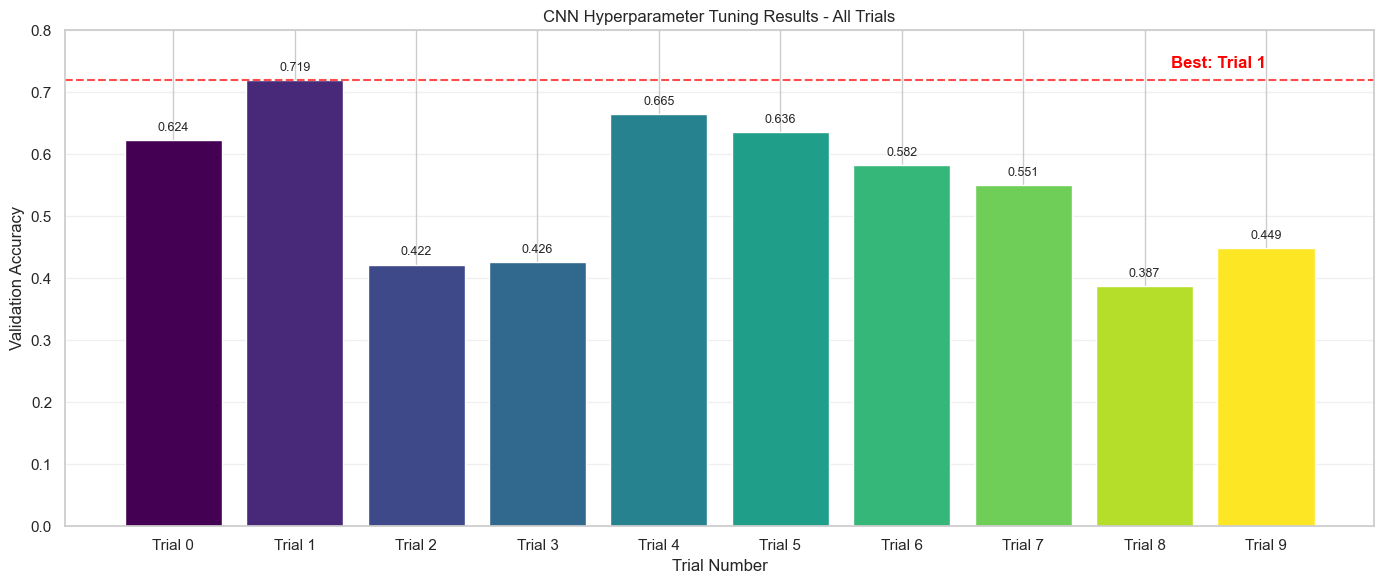

=====Detailed Information of the optimal configuration=====
Optimal configuration (Trial 1):
Validation accuracy: 0.7192
Filters: [32, 64]
Kernel Size: [3, 5]
Activation: relu
Padding: valid
Learning Rate: 0.001

Performance Statistics:
Best accuracy: 0.7192 (Trial 1)
Worst accuracy: 0.3874
Average accuracy: 0.5463
Number of trials: 10


In [123]:
# Read oracle.json and calculate trial time
oracle_path = os.path.join("keras_tuning_results", "cnn_tuning", "oracle.json")

with open(oracle_path, "r") as f:
    oracle_data = json.load(f)

trial_start = oracle_data["display"]["trial_start"]

# Convert the string to a pandas datetime and calculate the time difference
trial_times = {}
sorted_ids = sorted(trial_start.keys(), key=lambda x: int(x))
for i in range(len(sorted_ids)-1):
    tid = sorted_ids[i]
    t_start = pd.to_datetime(trial_start[tid])
    t_next  = pd.to_datetime(trial_start[sorted_ids[i+1]])
    trial_times[tid] = (t_next - t_start).total_seconds()


# First add up the previous trial time
last_tid = sorted_ids[-1]
total_known = sum([t for tid, t in trial_times.items() if tid != last_tid and t is not None])
# Subtract the sum of the previous trials from the total time
trial_times[last_tid] = round(cnn_elapsed - total_known, 2)

print("=== Each Trial requires (second) ===")
for tid, t in trial_times.items():
    print(f"Trial {tid}: {t:.3f} sec")

# Obtain all the detailed information of the trials
trials = cnn_tuner.oracle.trials
trial_data = []

for trial_id, trial in trials.items():
    if trial.status == "COMPLETED":
        trial_info = {
            'Trial': int(trial_id),
            'val_accuracy': trial.score if trial.score else 0,
            'filters_1': trial.hyperparameters.get('filters_1'),
            'filters_2': trial.hyperparameters.get('filters_2'), 
            'kernel_size_1': trial.hyperparameters.get('kernel_size_1'),
            'kernel_size_2': trial.hyperparameters.get('kernel_size_2'),
            'activation': trial.hyperparameters.get('activation'),
            'padding': trial.hyperparameters.get('padding'),
            'learning_rate': trial.hyperparameters.get('learning_rate')
        }
        trial_data.append(trial_info)

df = pd.DataFrame(trial_data)

# Sort by trial number
df = df.sort_values('Trial')

# Create a graph of hyperparameter tuning results
plt.figure(figsize=(14, 6))

# Create a bar plot - with the original trial order
bars = plt.bar(range(len(df)), df['val_accuracy'], 
               color=plt.cm.viridis(np.linspace(0, 1, len(df))))

plt.xlabel('Trial Number')
plt.ylabel('Validation Accuracy')
plt.title('CNN Hyperparameter Tuning Results - All Trials')
plt.xticks(range(len(df)), [f'Trial {i}' for i in df['Trial']])
plt.ylim(0, 0.8)
plt.grid(axis='y', alpha=0.3)


for bar, acc in zip(bars, df['val_accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# Mark the best trial
best_trial_idx = df['val_accuracy'].idxmax()
best_trial_num = df.loc[best_trial_idx, 'Trial']
plt.axhline(y=df.loc[best_trial_idx, 'val_accuracy'], color='red', linestyle='--', alpha=0.7)
plt.text(len(df)-1, df.loc[best_trial_idx, 'val_accuracy'] + 0.02, 
         f'Best: Trial {best_trial_num}', ha='right', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('cnn_hyperparameter_tuning_all_trials.png', dpi=300, bbox_inches='tight')
plt.show()

# Display detailed information of the optimal configuration
best_trial_row = df.loc[df['val_accuracy'].idxmax()]
print(f"=====Detailed Information of the optimal configuration=====")
print(f"Optimal configuration (Trial {best_trial_row['Trial']}):")
print(f"Validation accuracy: {best_trial_row['val_accuracy']:.4f}")
print(f"Filters: [{best_trial_row['filters_1']}, {best_trial_row['filters_2']}]")
print(f"Kernel Size: [{best_trial_row['kernel_size_1']}, {best_trial_row['kernel_size_2']}]")
print(f"Activation: {best_trial_row['activation']}")
print(f"Padding: {best_trial_row['padding']}")
print(f"Learning Rate: {best_trial_row['learning_rate']}")

# Display performance statistics
print(f"\nPerformance Statistics:")
print(f"Best accuracy: {df['val_accuracy'].max():.4f} (Trial {best_trial_row['Trial']})")
print(f"Worst accuracy: {df['val_accuracy'].min():.4f}")
print(f"Average accuracy: {df['val_accuracy'].mean():.4f}")
print(f"Number of trials: {len(df)}")

## 4. Final models

### 4.1 Get training data
This data is primarily for the SVM, as it has already completed the grid search and needs to be trained on the full training set.

For the CNN and MLP, valid datasets are still required during training.

Finally, all three models will be tested on the same test set.

In [81]:
X_train_full = np.concatenate([X_train, X_valid], axis=0)
y_train_full = np.concatenate([y_train, y_valid], axis=0)

### 4.2 SVM

In [85]:
# ---- timing helpers ----
def fmt_sec(s):
    m = int(s // 60)
    sec = s - 60 * m
    return f"{m:02d}m {sec:05.2f}s"

[Final SVM] test accuracy = 0.5747 | kernel=rbf, C=4.0, gamma=0.0005
Train time:   03m 45.05s  (225.05 s)
Predict time: 01m 06.42s  (66.42 s)
Total time:   04m 51.46s    (291.46 s)


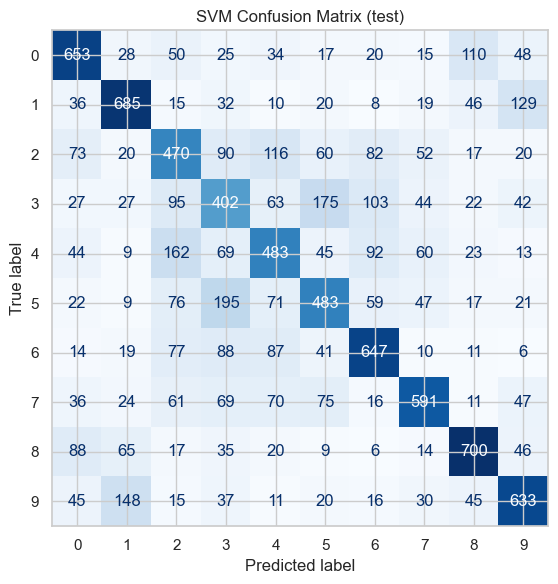


Saved: png/svm_confusion_matrix.png


In [86]:
# Final SVM (train on train∪valid, evaluate once on test)
# hard-coded best hyperparams (from 3.1.2)
BEST_KERNEL = "rbf"   
BEST_C      = 4.0
BEST_GAMMA  = 0.0005

# final pipeline (same preprocessing as tuning)
svm_est = SVC(
    kernel=BEST_KERNEL,
    C=BEST_C,
    gamma=(BEST_GAMMA if BEST_KERNEL == "rbf" else "scale"),
    probability=False,
    cache_size=2000
)
final_svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("pca", PCA(n_components=256, random_state=42)),
    ("svm", svm_est),
])

# flatten features (make this cell self-contained)
Xtr_full = X_train_full.reshape(len(X_train_full), -1)
Xte_full = X_test.reshape(len(X_test), -1)

# train on train∪valid, evaluate once on test
final_svm.fit(Xtr_full, y_train_full)
y_pred = final_svm.predict(Xte_full)
test_acc = accuracy_score(y_test, y_pred)

# train + predict timing 
t0 = time.time()
final_svm.fit(Xtr_full, y_train_full)
t1 = time.time()

y_pred = final_svm.predict(Xte_full)
t2 = time.time()

train_time   = t1 - t0
predict_time = t2 - t1
total_time   = t2 - t0

# ---- report ----
print(f"[Final SVM] test accuracy = {test_acc:.4f} | kernel={BEST_KERNEL}, C={BEST_C}, "
      f"gamma={(BEST_GAMMA if BEST_KERNEL=='rbf' else 'scale')}")
print(f"Train time:   {fmt_sec(train_time)}  ({train_time:.2f} s)")
print(f"Predict time: {fmt_sec(predict_time)}  ({predict_time:.2f} s)")
print(f"Total time:   {fmt_sec(total_time)}    ({total_time:.2f} s)")

# ---- confusion matrix (test) ----
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("SVM Confusion Matrix (test)")
plt.tight_layout()
plt.savefig('png/svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: png/svm_confusion_matrix.png")

### 4.3 Fully connected neural network

In [149]:
def plot_confusion_matrix(cm, classes, png_name, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """Prints and plots the confusion matrix."""
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(png_name + '_' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    if title == 'Confusion Matrix (Unnormalized)':
        plt.savefig(f"png/{png_name}.png", dpi=300, bbox_inches='tight')
    else:
        plt.savefig(f"png/{png_name}_normalized.png", dpi=300, bbox_inches='tight')
        
    plt.tight_layout()
    plt.show()

In [131]:
# Best Trial Configuration: Trial 07: Activation: relu, Optimizer: Adam, LR: 1.0E-04, L1:256, L2:256, L3:512
def build_final_mlp_model():
      
    UNITS = [256, 256, 512]
    ACTIVATION = "relu"
    LEARNING_RATE = 0.0001
    OPTIMIZER_NAME = "Adam"
    
    model = keras.Sequential()
    
    # Input & Flatten for CIFAR-10 (32x32x3) -> 3072 features
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Flatten())

    # Add 3 hidden layers
    for i in range(3):
        model.add(
            keras.layers.Dense(
                units=UNITS[i],
                activation=ACTIVATION
            )
        )

    # Output layer for 10 class classification (CIFAR-10)
    model.add(keras.layers.Dense(10, activation="softmax"))

    # Select Optimizer
    if OPTIMIZER_NAME == "SGD":
        optimizer = keras.optimizers.SGD(learning_rate=LEARNING_RATE)
    else: # Adam
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


final_mlp = build_final_mlp_model()

print("--- Starting Final MLP Training ---")
final_mlp.summary()

# Time
t0 = time.time()
history_mlp = final_mlp.fit(
    X_train, 
    y_train,
    epochs=100,      
    batch_size=128,  
    validation_data=(X_valid, y_valid),
)
t1 = time.time()
print(f"Training time: {(t1 - t0):.2f} seconds")

print("--- Final Training Complete ---")

t2 = time.time()
y_pred_probs = final_mlp.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
t3 = time.time()
print(f"Prediction time: {(t3 - t2):.2f} seconds")
print(f"Total time (train + predict): {(t3 - t0):.2f} seconds")

--- Starting Final MLP Training ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 989,194 (3.77 MB)

 Trainable params: 989,194 (3.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2697 - loss: 2.0205 - val_accuracy: 0.3776 - val_loss: 1.7615
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3883 - loss: 1.7199 - val_accuracy: 0.4114 - val_loss: 1.6718
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4231 - loss: 1.6293 - val_accuracy: 0.4298 - val_loss: 1.6040
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4436 - loss: 1.5694 - val_accuracy: 0.4426 - val_loss: 1.5594
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4611 - loss: 1.5210 - val_accuracy: 0.4542 - val_loss: 1.5319
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4765 - loss: 1.4796 - val_accuracy: 0.4606 - val_loss: 1.5075
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4894 - loss: 1.4447 - val_accuracy: 0.4696 - val_loss: 1.4868
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4997 - loss: 1.4139 - val_accu

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report (Test Set Performance: Precision, Recall, F1-Score)
              precision    recall  f1-score   support

    airplane     0.6233    0.5180    0.5658      1000
  automobile     0.6179    0.6130    0.6155      1000
        bird     0.3544    0.4380    0.3918      1000
         cat     0.3210    0.3220    0.3215      1000
        deer     0.3503    0.4950    0.4103      1000
         dog     0.3709    0.4610    0.4111      1000
        frog     0.6333    0.4300    0.5122      1000
       horse     0.4810    0.6200    0.5417      1000
        ship     0.6566    0.6080    0.6314      1000
       truck     0.7552    0.2930    0.4222      1000

    accuracy                         0.4798     10000
   macro avg     0.5164    0.4798    0.4823     10000
weighted avg     0.5164    0.4798    0.4823     10000

Confusion matrix, without normalization


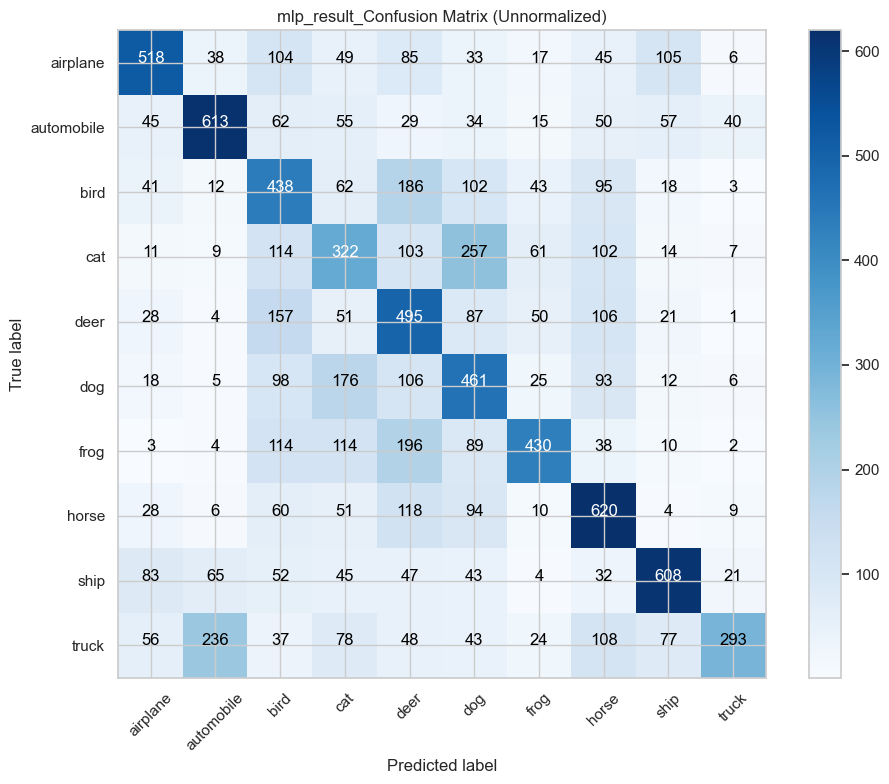

Normalized confusion matrix


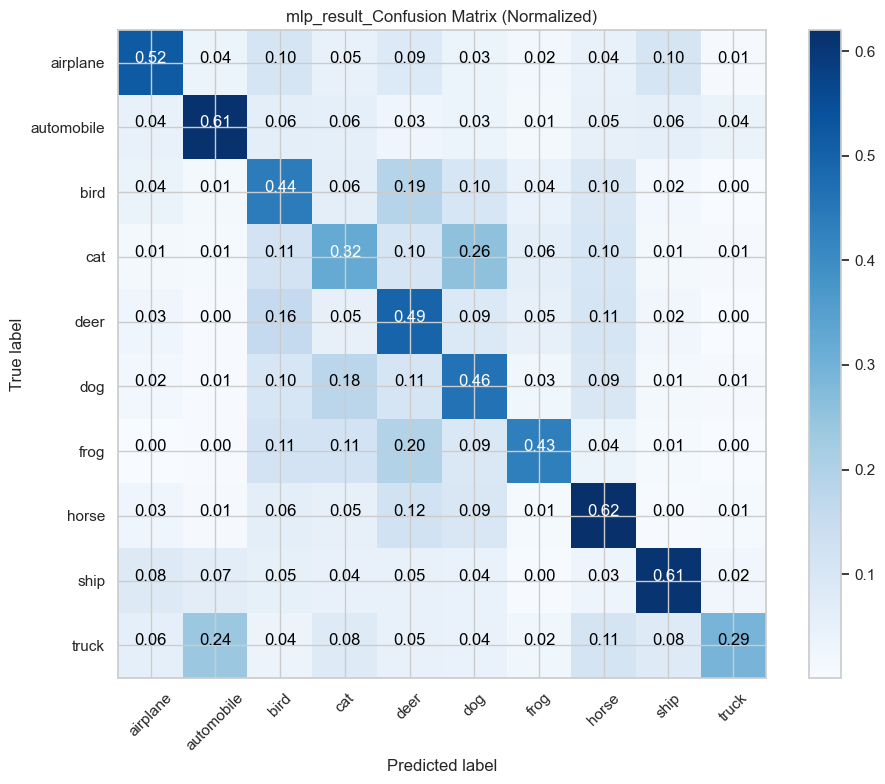


--- Evaluation and Plotting Complete ---


In [150]:
# Show the model result
mlp_y_pred_probs = final_mlp.predict(X_test)
mlp_y_pred = np.argmax(mlp_y_pred_probs, axis=1)

y_true = y_test 

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']


print("\n" + "="*50)
print("Classification Report (Test Set Performance: Precision, Recall, F1-Score)")
print("="*50)

print(classification_report(y_true, mlp_y_pred, target_names=class_names, digits=4))


# Confusion matrices
cm = confusion_matrix(y_true, mlp_y_pred)
plot_confusion_matrix(cm, png_name = 'mlp_result', classes=class_names, title='Confusion Matrix (Unnormalized)')
plot_confusion_matrix(cm, png_name = 'mlp_result', classes=class_names, normalize=True, title='Confusion Matrix (Normalized)')


print("\n--- Evaluation and Plotting Complete ---")

### 4.4 Convolutional neural network

In [133]:
# Optimal Hyperparameters 
filters_1 = 32
filters_2 = 64
kernel_size_1 = 3
kernel_size_2 = 5
activation = "relu"
padding = "valid"
learning_rate = 0.001

# Final CNN
def build_final_cnn():
    model = keras.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))
    
    # Convolutional Block 1
    model.add(layers.Conv2D(
        filters=filters_1,  
        kernel_size=(kernel_size_1, kernel_size_1),  
        activation=activation,
        padding=padding  
    ))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # Convolutional Block 2
    model.add(layers.Conv2D(
        filters=filters_2, 
        kernel_size=(kernel_size_2, kernel_size_2), 
        activation=activation,  
        padding=padding  
    ))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # Classification Head
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    
    # Compile with optimal learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Early stopping callback
early_stopping = callbacks.EarlyStopping(
    monitor='loss',                   
    min_delta=0.001,                  
    patience=15,                      
    restore_best_weights=True,      
    verbose=1                         
)

# Time
start_time = time.time()

final_cnn = build_final_cnn()
history_cnn = final_cnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    verbose=1,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping]
)
cnn_time = time.time() - start_time
print(f"Final CNN training completed in {cnn_time:.2f} seconds")

# epoch
actual_epochs = len(history_cnn.history['accuracy'])
print(f"Training stopped at epoch {actual_epochs}")

# Report
cnn_best_params = f"""filters=[{filters_1},{filters_2}], 
kernel={kernel_size_1}x{kernel_size_2}, 
activation={activation}, 
lr={learning_rate}"""

print(f"Best parameters: {cnn_best_params}")

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2804 - loss: 1.9633 - val_accuracy: 0.4818 - val_loss: 1.4558
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4635 - loss: 1.4902 - val_accuracy: 0.5416 - val_loss: 1.3120
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5163 - loss: 1.3545 - val_accuracy: 0.5780 - val_loss: 1.2218
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5491 - loss: 1.2698 - val_accuracy: 0.5970 - val_loss: 1.1665
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5762 - loss: 1.2108 - val_accuracy: 0.6204 - val_loss: 1.1125
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5919 - loss: 1.1677 - val_accuracy: 0.6306 - val_loss: 1.0840
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6025 - loss: 1.1332 - val_accuracy: 0.6414 - val_loss: 1.0642
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6158 - loss: 1.1043 - 

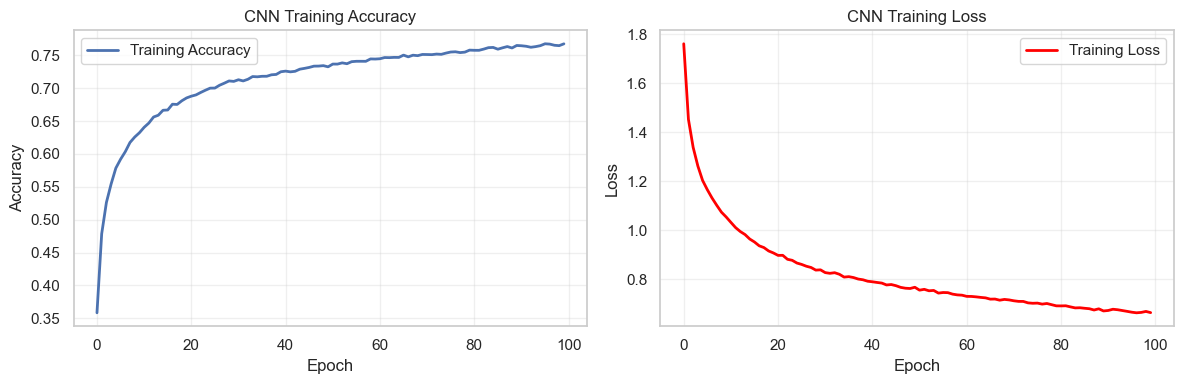

In [134]:
plt.figure(figsize=(12, 4))

# The Accuracy curve 
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# The Loss curve
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (Test Set Performance: Precision, Recall, F1-Score)
              precision    recall  f1-score   support

    airplane     0.7574    0.7400    0.7486      1000
  automobile     0.8839    0.8220    0.8518      1000
        bird     0.7133    0.5350    0.6114      1000
         cat     0.5376    0.5930    0.5640      1000
        deer     0.7474    0.6420    0.6907      1000
         dog     0.6784    0.6370    0.6570      1000
        frog     0.7325    0.8600    0.7912      1000
       horse     0.7112    0.8150    0.7596      1000
        ship     0.8169    0.8520    0.8341      1000
       truck     0.7868    0.8490    0.8167      1000

    accuracy                         0.7345     10000
   macro avg     0.7365    0.7345    0.7325     10000
weighted avg     0.7365    0.7345    0.7325     10000

Confusion matrix, without normalization


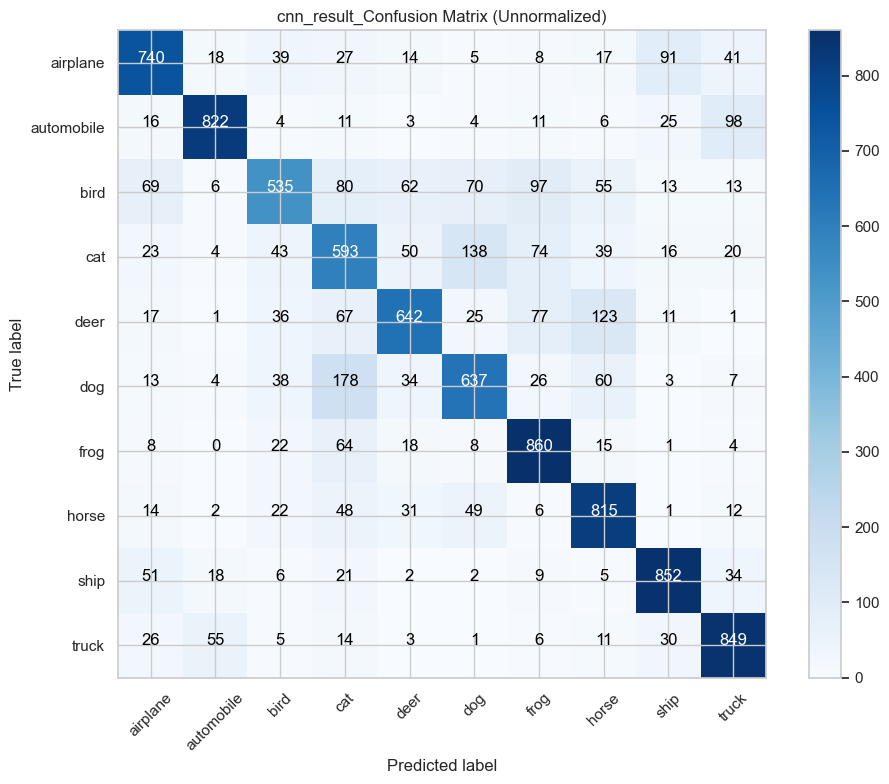

Normalized confusion matrix


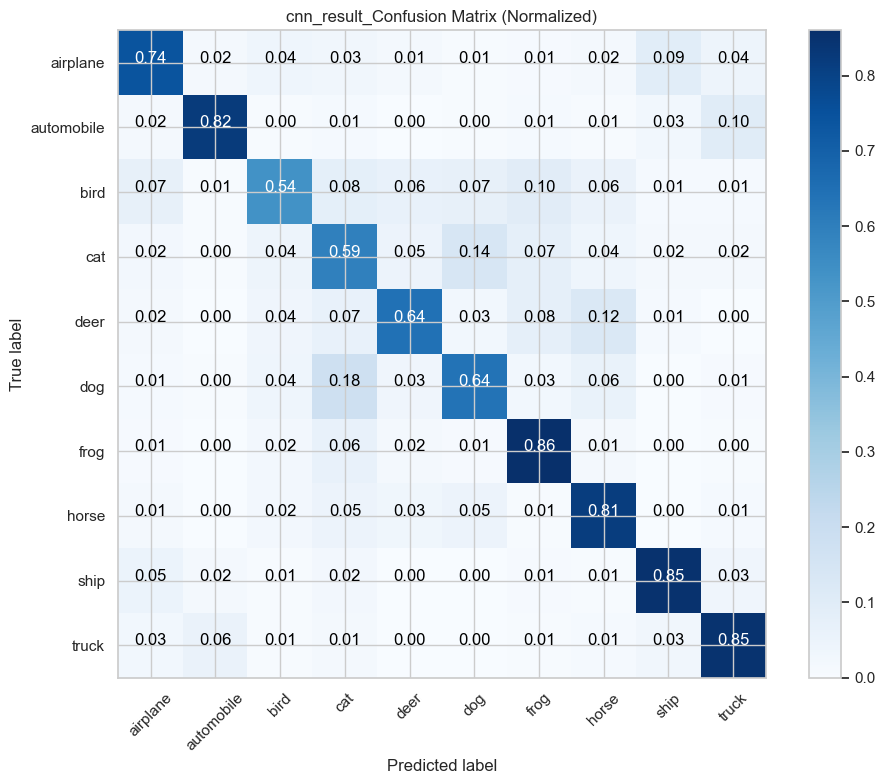


--- Evaluation and Plotting Complete ---


In [151]:
# Show the model result
cnn_y_pred_probs = final_cnn.predict(X_test)
cnn_y_pred = np.argmax(cnn_y_pred_probs, axis=1)

y_true = y_test 

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']


print("\n" + "="*50)
print("Classification Report (Test Set Performance: Precision, Recall, F1-Score)")
print("="*50)

print(classification_report(y_true, cnn_y_pred, target_names=class_names, digits=4))


# Confusion matrices
cm = confusion_matrix(y_true, cnn_y_pred)
plot_confusion_matrix(cm, png_name = 'cnn_result', classes=class_names, title='Confusion Matrix (Unnormalized)')
plot_confusion_matrix(cm, png_name = 'cnn_result', classes=class_names, normalize=True, title='Confusion Matrix (Normalized)')


print("\n--- Evaluation and Plotting Complete ---")

# Thank you